# Linear Regression on CO2 Dataset
Predicting CO2 emissions from combined fuel consumption using only pandas, numpy and matplotlib.

## Step 1: Load and clean the data

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("co2.csv")

df["Model"] = df["Model"].str.strip().str.upper()
df["Make"] = df["Make"].str.strip().str.upper()
df = df.drop_duplicates().reset_index(drop = True)
df.columns = ["make", "model", "vclass", "engine", "cylinders", "trans", "fuel", "city", "hwy", "comb", "comb_mpg", "co2"]

print(df.shape)

(5990, 12)


**Observation:** After removing duplicate rows, 5,990 cars remain.

## Step 2: Split into train and test

In [26]:
df = df.sample(frac=1, random_state=42).reset_index(drop = True)
cut = int(len(df)*0.8)
train = df[:cut].copy()
test = df[cut:].copy()
print("Training cars:",len(train))
print("Testing cars:",len(test))

Training cars: 4792
Testing cars: 1198


**Observation:** 4,792 cars (80%) are used to train the model and 1,198 cars (20%) are kept aside to test it.

## Step 3: Find the best line
Calculate the slope (m) and intercept (c) of the line CO2 = m × comb + c.

In [27]:
x = train["comb"]
y = train["co2"]

m = ((x - x.mean()) * (y - y.mean())).sum()/((x - x.mean()) ** 2).sum()
c = y.mean() - m * x.mean()

print("Slope(m):", round(m,2))
print("Intercept(c):", round(c,2))
print(f"Equation: CO2 = {m:.2f} * comb + {c:.2f}")

Slope(m): 18.13
Intercept(c): 51.12
Equation: CO2 = 18.13 * comb + 51.12


**Observation:** The best line is CO2 = 18.13 × comb + 51.12, so every extra 1 L/100 km of fuel adds about 18 g/km of CO2.

## Step 4: Make predictions

In [28]:
test["prediction"] = m * test["comb"] + c
test[["comb", "co2", "prediction"]].head(10)

,comb,co2,prediction
4792,10.2,238,236.082783
4793,8.9,208,212.508638
4794,9.2,215,217.948825
4795,8.0,188,196.188077
4796,9.5,218,223.389013
4797,9.6,221,225.202408
4798,10.7,249,245.149762
4799,18.0,288,377.527651
4800,14.8,340,319.498987
4801,7.0,164,178.054119


**Observation:** Most predictions are close to the actual CO2 values, but some cars (like the one using 18 L/100 km) are predicted too high.

## Step 5: Evaluate the model

In [31]:
error = test["co2"] - test["prediction"]

mae = error.abs().mean()
rmse = np.sqrt((error ** 2).mean())
r2 = 1 - (error ** 2).sum()/((test["co2"] - test["co2"].mean()) ** 2).sum()

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2:", round(r2, 3))

Mean Absolute Error: 13.99
Root Mean Squared Error: 22.0
R2: 0.862


**Observation:** The model explains about 86% of the variation in CO2 (R² = 0.862), and predictions are off by about 14 g/km on average (MAE = 13.99).

## Step 6: Plot the result

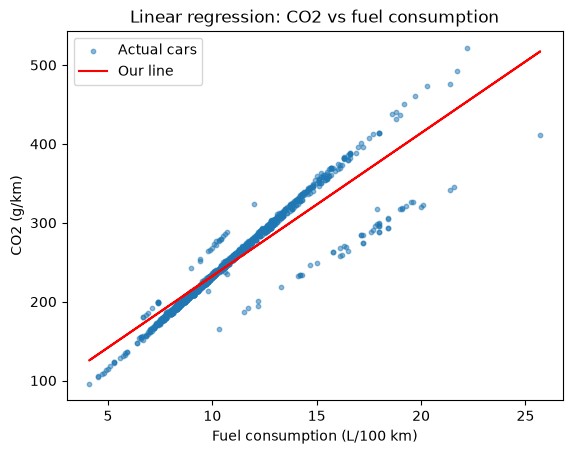

In [30]:
plt.scatter(test["comb"], test["co2"], s=10, alpha=0.5, label="Actual cars")
plt.plot(test["comb"], test["prediction"], color = "red", label = "Our line")
plt.xlabel("Fuel consumption (L/100 km)")
plt.ylabel("CO2 (g/km)")
plt.title("Linear regression: CO2 vs fuel consumption")
plt.legend()
plt.show()

**Observation:** The line follows the overall trend, but the dots form several separate lines (one per fuel type), which a single straight line cannot capture.

## Conclusions
- Using only fuel consumption, the model predicts CO2 with R² ≈ 0.86.
- Every extra litre per 100 km adds about 18 g/km of CO2.
- The predictions are off by about 14 g/km on average.
- The model is less accurate because different fuel types produce different amounts of CO2 per litre, which one straight line cannot capture.